# Dynamic Control and Setpoint Changes

Time-domain simulations typically use fixed parameters throughout the simulation period. However, many advanced applications require changing control setpoints during simulation, such as implementing economic dispatch schedules, testing automatic generation control (AGC), or integrating with reinforcement learning algorithms. ANDES supports this through its multi-stage simulation capability.

The key insight is that `ss.TDS.run()` can be called multiple times, each time advancing the simulation from the current state to a new end time. Between calls, you can modify setpoints, reference values, or other parameters, and the simulation will continue from exactly where it left off.

This tutorial demonstrates how to change generator power setpoints during simulation and observe the dynamic response.

:::{note}
**Prerequisites:** Complete {doc}`04-time-domain` for time-domain simulation basics and {doc}`05-data-and-formats` for parameter modification techniques.
:::

In [1]:
# Reduce logging verbosity for PDF builds
import os
if os.environ.get('SPHINX_BUILD_PDF'):
    import andes
    _orig_config_logger = andes.config_logger
    def _quiet_logger(stream_level=20, *args, **kwargs):
        stream_level = max(stream_level, 30)
        return _orig_config_logger(stream_level, *args, **kwargs)
    andes.config_logger = _quiet_logger

## Setup

In [2]:
%matplotlib inline

import andes

andes.config_logger(stream_level=20)

## Initialize the System

First, we load the system and run power flow to establish the initial operating point. We also disable any pre-existing disturbances (like the Toggle in the Kundur test case) so we can observe only the effects of our setpoint changes.

In [3]:
kundur = andes.get_case('kundur/kundur_full.xlsx')
ss = andes.run(kundur)

Working directory: "/home/hcui9/repos/andes/docs/source/tutorials"


> Loaded config from file "/home/hcui9/.andes/andes.rc"


> Loaded generated Python code in "/home/hcui9/.andes/pycode".


Parsing input file "/home/hcui9/repos/andes/andes/cases/kundur/kundur_full.xlsx"...


Input file parsed in 0.0200 seconds.


...

3: |F(x)| = 0.002038626956


4: |F(x)| = 3.745104015e-07


Converged in 5 iterations in 0.0030 seconds.


Report saved to "kundur_full_out.txt" in 0.0007 seconds.


-> Single process finished in 0.3479 seconds.


In [4]:
# Disable the pre-existing Toggle to have a clean experiment
ss.Toggle.set_status(1, 0)

## Understanding Turbine Governor Setpoints

ANDES provides a group-level setpoint API that automatically resolves the controller chain. For example, `ss.SynGen.set_paux()` locates the turbine governor connected to a given generator and writes to its auxiliary power input. The user does not need to know which governor model is in use.

Under the hood, the TGOV1 turbine governor model contains a power reference input `pref0` and an auxiliary power input `paux0`. The following code examines the TGOV1 model structure to illustrate where these setpoints enter the equations.

In [5]:
# View the TGOV1 algebraic equations to see how pref0 and paux0 are used
print("TGOV1 Algebraic Equations:")
for var_name in ['pref', 'paux', 'pd']:
    var = getattr(ss.TGOV1, var_name)
    print(f"  {var_name}: {var.e_str}")

TGOV1 Algebraic Equations:
  pref: pref0 * R - pref
  paux: paux0 - paux
  pd: ue*(- wd + pref + paux) * gain - pd


The equation `pref0 - pref = 0` indicates that the algebraic variable `pref` tracks the parameter `pref0`, which serves as the base power reference. Similarly, `paux0 - paux = 0` tracks the auxiliary power input `paux0`. Both `pref` and `paux` feed into the `pd` equation, ultimately affecting the turbine mechanical power output.

The group-level API `set_paux()` writes to `paux0`, while `set_pref()` writes to `pref0`. Both methods resolve the controller chain automatically.

The initial values of `paux0` for all generators are shown below.

In [6]:
print(f"Initial paux0 values: {ss.TGOV1.paux0.v}")

Initial paux0 values: [0. 0. 0. 0.]


## Stage 1: Run Simulation to Steady State

We first run the simulation for one second with no setpoint changes. This establishes a baseline and confirms the system is in steady state before we apply any changes.

In [7]:
# Set the first stopping time
ss.TDS.config.tf = 1
ss.TDS.run()

DAE compaction: removed 5 algebraic variable slots (m: 149 -> 144)


Initialization for dynamics completed in 0.0084 seconds.


Initialization was successful.


Simulation to t=1.00 sec completed in 0.0163 seconds.


Outputs to "kundur_full_out.lst" and "kundur_full_out.npz".


Outputs written in 0.0013 seconds.


True

### Finding a Generator by Bus Number

A common task is "change the voltage setpoint of the generator at bus 2" — but you only know the bus number, not the generator index. The `find_connected()` method bridges this gap by returning all devices that reference a given bus or device.

Combined with the setpoint API, this eliminates the need to manually trace through PV → StaticGen → GENROU → exciter → VREF0.

In [8]:
# Step 1: Find what's connected to bus 2
connected = ss.find_connected('Bus', 2)
print("Devices at bus 2:")
for model, idxes in connected.items():
    print(f"  {model}: {idxes}")

# Step 2: Get the generator idx from the result
gen_at_bus2 = connected['GENROU'][0]
print(f"\nGenerator at bus 2: {gen_at_bus2}")

# Step 3: Read and change the voltage setpoint
original_vref = ss.SynGen.get_vref(ss, gen_at_bus2)
print(f"Current vref: {original_vref:.4f}")

ss.SynGen.set_vref(ss, gen_at_bus2, 1.05)
print(f"Updated vref: {ss.SynGen.get_vref(ss, gen_at_bus2):.4f}")

# Restore for the rest of this tutorial (which demonstrates set_paux)
ss.SynGen.set_vref(ss, gen_at_bus2, original_vref)

Devices at bus 2:
  PV: [2]
  Line: ['Line_12']
  GENROU: [2]

Generator at bus 2: 2
Current vref: 1.1010
Updated vref: 1.0500


## Stage 2: Apply Setpoint Change

The auxiliary power setpoint of the first generator is increased by 0.05 pu. This change simulates a dispatch command instructing the generator to increase its output.

The recommended approach is the group-level setpoint API, which resolves the controller chain automatically. The generator index is specified, and the API locates the connected governor internally.

In [9]:
# Get the first generator's idx
gen_idx = ss.GENROU.idx.v[0]

# Increase the auxiliary power by 0.05 pu (system base)
ss.SynGen.set_paux(ss, gen_idx, 0.05)

print(f"Updated paux: {ss.SynGen.get_paux(ss, gen_idx)}")

Updated paux: 0.05


In [10]:
# Continue simulation to 2 seconds
ss.TDS.config.tf = 2
ss.TDS.run()

Simulation to t=2.00 sec completed in 0.0344 seconds.


Outputs to "kundur_full_out.lst" and "kundur_full_out.npz".


Outputs written in 0.0021 seconds.


True

Let us plot the auxiliary power input to see the step change.

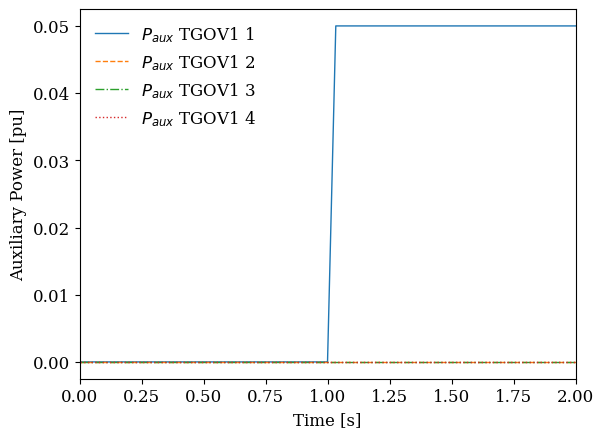

In [11]:
fig, ax = ss.TDS.plt.plot(ss.TGOV1.paux, ylabel='Auxiliary Power [pu]')

The plot shows that `paux` for the first generator stepped from 0 to 0.05 pu at t=1 second. This change propagates through the turbine governor dynamics to affect the mechanical power output.

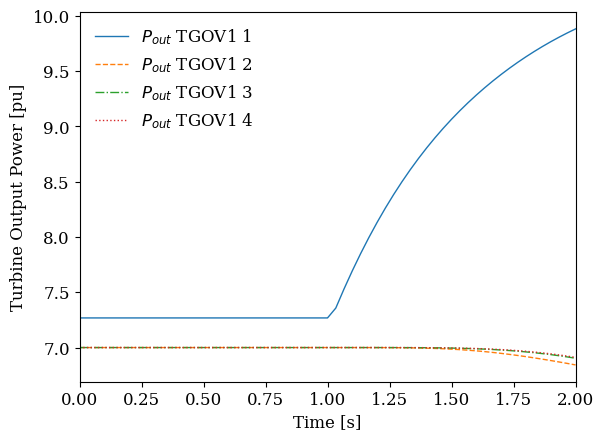

In [12]:
fig, ax = ss.TDS.plt.plot(ss.TGOV1.pout, ylabel='Turbine Output Power [pu]')

The turbine output power increases for the first generator (blue curve) following the setpoint change. The response is not instantaneous because the turbine governor has dynamics (lag and lead-lag blocks) that smooth the response.

The generator speeds also respond to this power imbalance.

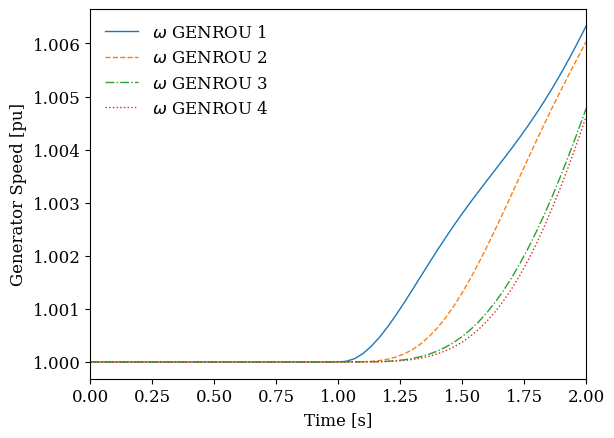

In [13]:
fig, ax = ss.TDS.plt.plot(ss.GENROU.omega, ylabel='Generator Speed [pu]')

## Stage 3: Restore Setpoint

The auxiliary power is reset to zero, and the system is observed returning to its original operating point. This demonstrates that the simulation correctly tracks multiple setpoint changes.

In [14]:
# Reset the auxiliary power
ss.SynGen.set_paux(ss, gen_idx, 0.0)

# Continue simulation to 10 seconds
ss.TDS.config.tf = 10
ss.TDS.run()

Simulation to t=10.00 sec completed in 0.2734 seconds.


Outputs to "kundur_full_out.lst" and "kundur_full_out.npz".


Outputs written in 0.0086 seconds.


True

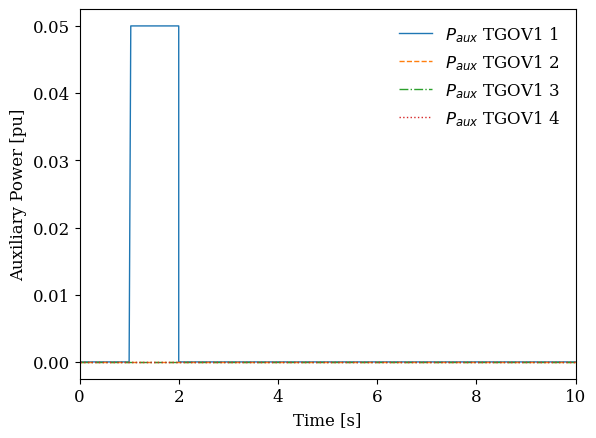

In [15]:
fig, ax = ss.TDS.plt.plot(ss.TGOV1.paux, ylabel='Auxiliary Power [pu]')

The auxiliary power shows two transitions: up at t=1s and back down at t=2s. The generator speeds show the corresponding dynamics as the system adjusts to each change.

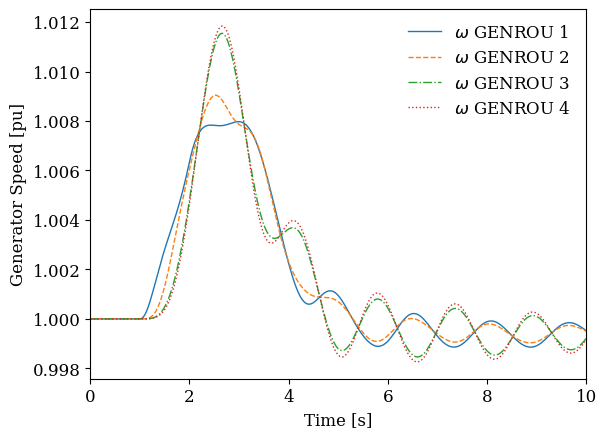

In [16]:
fig, ax = ss.TDS.plt.plot(ss.GENROU.omega, ylabel='Generator Speed [pu]')

## Applications

The multi-stage simulation capability enables several advanced applications. The group-level setpoint API (`set_pref`, `set_vref`, `set_paux`, `set_qref`) is recommended because it resolves the controller chain automatically.

| Application | Recommended API | Description |
|-------------|----------------|-------------|
| Economic dispatch | `SynGen.set_pref()` | Follow dispatch schedules |
| AGC simulation | `SynGen.set_paux()` | Frequency regulation signals |
| Voltage control | `SynGen.set_vref()` | Voltage setpoint tracking |
| Renewable dispatch | `RenGen.set_pref()` / `set_qref()` | P and Q reference changes |
| Reinforcement learning | `GroupBase.set_setpoint()` | Generic setpoint interface |

The key technique is the same in all cases: the simulation is run to a checkpoint, the relevant setpoint is modified through the API, and the simulation is continued.

:::{note}
**Advanced usage.** For bulk operations or model-specific parameters not covered by the setpoint API (e.g., modifying all governor `paux0` values simultaneously), direct in-place array assignment remains available:

```python
ss.TGOV1.paux0.v[:] = new_values  # in-place update of the entire array
```

When modifying arrays directly, in-place assignment (e.g., `array[0] = value` or `array[:] = values`) must be used rather than replacing the array reference. Replacing the reference (e.g., `array = new_array`) disconnects the variable from the simulation.
:::

## Cleanup

In [17]:
!andes misc -C

"/home/hcui9/repos/andes/docs/source/tutorials/kundur_full_out.lst" removed.
"/home/hcui9/repos/andes/docs/source/tutorials/kundur_full_out.npz" removed.
"/home/hcui9/repos/andes/docs/source/tutorials/kundur_full_out.txt" removed.


## Next Steps

- {doc}`11-frequency-response` - Frequency response analysis
- {doc}`07-eigenvalue-analysis` - Small-signal stability analysis
- {doc}`08-parameter-sweeps` - Batch simulation techniques